In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
import pandas as pd
import requests

# URL for the NYPD Arrests Data (Year to Date) from NYC Open Data
# This URL directly downloads the CSV file.
data_url = "https://data.cityofnewyork.us/api/views/uip8-fykc/rows.csv?accessType=DOWNLOAD"
output_filename = "NYPD_ARREST_DATA_YEAR_TO_DATE.csv"

try:
    # Use requests to download the file
    response = requests.get(data_url, stream=True)
    response.raise_for_status() # Raise an exception for bad status codes

    with open(output_filename, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)

    print(f"Successfully downloaded '{output_filename}'")

    # Optional: Load the downloaded CSV into a pandas DataFrame to preview
    # df = pd.read_csv(output_filename)
    # print("First 5 rows of the downloaded data:")
    # print(df.head())

except requests.exceptions.RequestException as e:
    print(f"Error downloading the file: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Successfully downloaded 'NYPD_ARREST_DATA_YEAR_TO_DATE.csv'


In [19]:
arrest_data = pd.read_csv('NYPD_ARREST_DATA_YEAR_TO_DATE.csv')
arrest_data.head()

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,299201470,01/10/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,F,WHITE,1017105,210917,40.745543,-73.881427,POINT (-73.881427 40.745543)
1,299351927,01/13/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,S,120,0,25-44,M,BLACK,962808,174275,40.645005,-74.077265,POINT (-74.077265 40.645005)
2,299366743,01/13/2025,157,RAPE 1,104.0,RAPE,PL 130351A,F,B,46,0,25-44,M,BLACK HISPANIC,1011755,250279,40.853598,-73.900577,POINT (-73.9005768807295 40.8535983673823)
3,300990163,02/12/2025,153,RAPE 3,104.0,RAPE,PL 1302504,F,K,77,0,(null),(null),BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)
4,301010124,02/12/2025,157,RAPE 1,104.0,RAPE,PL 130353A,F,K,77,0,25-44,M,BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)


In [20]:
arrest_data.tail()

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
278948,318159497,12/30/2025,339,"LARCENY,PETIT FROM OPEN AREAS,",341.0,PETIT LARCENY,PL 1552500,M,K,70,0,(null),(null),BLACK,999359,169275,40.631293,-73.945566,POINT (-73.945566 40.631293)
278949,318206208,12/31/2025,101,ASSAULT 3,344.0,ASSAULT 3 & RELATED OFFENSES,PL 1200001,M,M,25,0,25-44,F,BLACK,1000581,231070,40.800904,-73.941012,POINT (-73.941012 40.800904)
278950,318144122,12/30/2025,101,ASSAULT 3,344.0,ASSAULT 3 & RELATED OFFENSES,PL 1200001,M,Q,110,0,18-24,F,BLACK,1024817,213376,40.752260,-73.853581,POINT (-73.853581 40.75226)
278951,318209021,12/31/2025,779,"PUBLIC ADMINISTRATION,UNCLASSI",126.0,MISCELLANEOUS PENAL LAW,PL 215510B,F,Q,109,0,25-44,M,BLACK HISPANIC,1040185,217007,40.762143,-73.798083,POINT (-73.798083 40.762143)
278952,318207879,12/31/2025,922,"TRAFFIC,UNCLASSIFIED MISDEMEAN",348.0,VEHICLE AND TRAFFIC LAWS,VTL0511001,M,S,120,0,(null),(null),WHITE HISPANIC,964114,166065,40.622464,-74.072535,POINT (-74.07253516 40.62246362)


In [21]:
arrest_data.shape

(278953, 19)

In [22]:
arrest_data.columns

Index(['ARREST_KEY', 'ARREST_DATE', 'PD_CD', 'PD_DESC', 'KY_CD', 'OFNS_DESC',
       'LAW_CODE', 'LAW_CAT_CD', 'ARREST_BORO', 'ARREST_PRECINCT',
       'JURISDICTION_CODE', 'AGE_GROUP', 'PERP_SEX', 'PERP_RACE', 'X_COORD_CD',
       'Y_COORD_CD', 'Latitude', 'Longitude', 'Location'],
      dtype='object')

In [23]:
#filtering for felony 'F'


In [24]:
felony_arrests = arrest_data[arrest_data['LAW_CAT_CD'] == 'F']
print("Shape of felony arrests data:", felony_arrests.shape)
felony_arrests.head()

Shape of felony arrests data: (111419, 19)


,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,299201470,01/10/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,F,WHITE,1017105,210917,40.745543,-73.881427,POINT (-73.881427 40.745543)
1,299351927,01/13/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,S,120,0,25-44,M,BLACK,962808,174275,40.645005,-74.077265,POINT (-74.077265 40.645005)
2,299366743,01/13/2025,157,RAPE 1,104.0,RAPE,PL 130351A,F,B,46,0,25-44,M,BLACK HISPANIC,1011755,250279,40.853598,-73.900577,POINT (-73.9005768807295 40.8535983673823)
3,300990163,02/12/2025,153,RAPE 3,104.0,RAPE,PL 1302504,F,K,77,0,(null),(null),BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)
4,301010124,02/12/2025,157,RAPE 1,104.0,RAPE,PL 130353A,F,K,77,0,25-44,M,BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)


In [25]:
#filtering for felonies in Brooklyn
brooklyn_arrests = arrest_data[arrest_data['ARREST_BORO'] == 'K']
print("Shape of Brooklyn arrests data:", brooklyn_arrests.shape)
brooklyn_arrests.head()

Shape of Brooklyn arrests data: (79882, 19)


,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
3,300990163,02/12/2025,153,RAPE 3,104.0,RAPE,PL 1302504,F,K,77,0,(null),(null),BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)
4,301010124,02/12/2025,157,RAPE 1,104.0,RAPE,PL 130353A,F,K,77,0,25-44,M,BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)
9,303343948,03/21/2025,153,RAPE 3,104.0,RAPE,PL 1302507,F,K,78,0,25-44,M,WHITE HISPANIC,991330,187303,40.680786,-73.974475,POINT (-73.9744751162161 40.6807856126343)
10,303620708,03/25/2025,263,"ARSON 2,3,4",114.0,ARSON,PL 1501500,F,K,69,71,25-44,M,WHITE,1014039,172089,40.638981,-73.892664,POINT (-73.892664 40.638981)
15,305990831,05/07/2025,177,SEXUAL ABUSE,116.0,SEX CRIMES,PL 1306504,F,K,78,0,45-64,M,BLACK,991330,187303,40.680786,-73.974475,POINT (-73.9744751162161 40.6807856126343)


In [26]:
#filtering for felonies in Queens
queens_arrests = arrest_data[arrest_data['ARREST_BORO'] == 'Q']
print("Shape of Queens arrests data:", queens_arrests.shape)
queens_arrests.head()

Shape of Queens arrests data: (58083, 19)


,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,299201470,01/10/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,F,WHITE,1017105,210917,40.745543,-73.881427,POINT (-73.881427 40.745543)
16,306159756,05/09/2025,153,RAPE 3,104.0,RAPE,PL 1302507,F,Q,116,0,<18,M,BLACK,1057893,182156,40.666286,-73.734144,POINT (-73.734144 40.666286)
17,308184003,06/17/2025,155,RAPE 2,104.0,RAPE,PL 1303001,F,Q,112,0,25-44,M,BLACK,1025401,202586,40.722641,-73.851542,POINT (-73.8515418216779 40.7226409964758)
19,308957218,07/02/2025,153,RAPE 3,104.0,RAPE,PL 1302501,F,Q,112,0,(null),(null),BLACK,1025401,202586,40.722641,-73.851542,POINT (-73.8515418216779 40.7226409964758)
22,311287118,08/16/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211300,F,Q,113,0,25-44,M,BLACK,1046089,185885,40.676681,-73.777057,POINT (-73.777057 40.676681)


In [27]:
#Total number of felonies in Brooklyn
brooklyn_felonies = brooklyn_arrests[brooklyn_arrests['LAW_CAT_CD'] == 'F']
total_brooklyn_felonies = brooklyn_felonies.shape[0]
print(f"Total felonies in Brooklyn: {total_brooklyn_felonies}")

Total felonies in Brooklyn: 32844


In [28]:
#Total number of felonies in Queens
queens_felonies = queens_arrests[queens_arrests['LAW_CAT_CD'] == 'F']
total_queens_felonies = queens_felonies.shape[0]
print(f"Total felonies in Queens: {total_queens_felonies}")

Total felonies in Queens: 23839


/tmp/ipykernel_2727/1718926655.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=districts, y=felony_counts, palette='viridis')


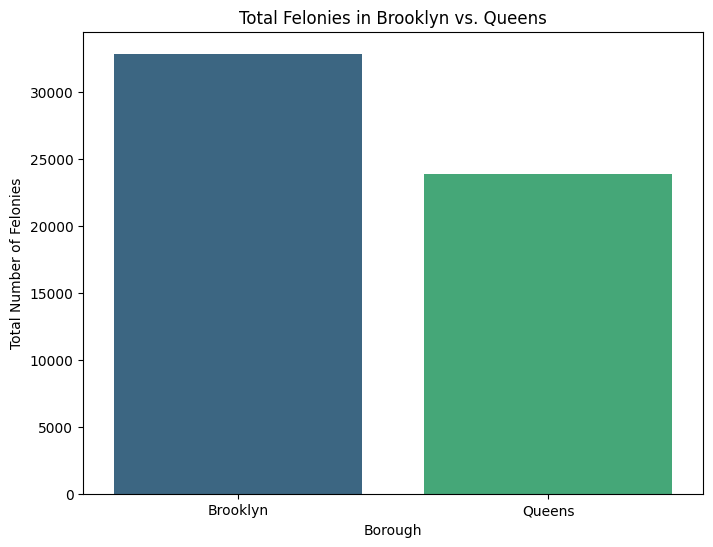

In [29]:
districts = ['Brooklyn' , 'Queens']
felony_counts = [total_brooklyn_felonies, total_queens_felonies]
plt.figure(figsize=(8, 6))
sns.barplot(x=districts, y=felony_counts, palette='viridis')
plt.title('Total Felonies in Brooklyn vs. Queens')
plt.xlabel('Borough')
plt.ylabel('Total Number of Felonies')
plt.show()

From the visualization, I can conclude that Queens has less felonies than of Brooklyn.